In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Cargar dataset limpio

ruta = "../Datos/datos_limpios_coberturas_vacunacion.csv"

df = pd.read_csv(ruta)

df.head()

,cod_departamento,departamento,anio,biologico,cobertura_vacunacion,estado_indicador,rango_bajo_inicio,rango_bajo_fin,rango_medio_inicio,rango_medio_fin,rango_adecuado_inicio,rango_adecuado_fin,cobertura_original,cobertura_porcentaje,nivel_cobertura
0,5,Antioquia,2019,BCG - Antituberculosa Recién Nacido,0.9389,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99,0.9389,93.89,Adecuada
1,8,Atlántico,2019,BCG - Antituberculosa Recién Nacido,1.0379,IndicatorState3,0,49.99,80,89.99,90,94.99,10379.0000,103.79,Alta
2,11,Bogotá D.C.,2019,BCG - Antituberculosa Recién Nacido,1.0105,IndicatorState3,0,49.99,80,89.99,90,94.99,10105.0000,101.05,Alta
3,13,Bolívar,2019,BCG - Antituberculosa Recién Nacido,0.7170,IndicatorState1,0,49.99,80,89.99,90,94.99,0.7170,71.70,Baja
4,15,Boyacá,2019,BCG - Antituberculosa Recién Nacido,0.9409,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99,0.9409,94.09,Adecuada


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cod_departamento       660 non-null    int64  
 1   departamento           660 non-null    str    
 2   anio                   660 non-null    int64  
 3   biologico              660 non-null    str    
 4   cobertura_vacunacion   660 non-null    float64
 5   estado_indicador       660 non-null    str    
 6   rango_bajo_inicio      660 non-null    int64  
 7   rango_bajo_fin         660 non-null    float64
 8   rango_medio_inicio     660 non-null    int64  
 9   rango_medio_fin        660 non-null    float64
 10  rango_adecuado_inicio  660 non-null    int64  
 11  rango_adecuado_fin     660 non-null    float64
 12  cobertura_original     660 non-null    float64
 13  cobertura_porcentaje   660 non-null    float64
 14  nivel_cobertura        660 non-null    str    
dtypes: float64(6), in

In [9]:
df.columns

Index(['cod_departamento', 'departamento', 'anio', 'biologico',
       'cobertura_vacunacion', 'estado_indicador', 'rango_bajo_inicio',
       'rango_bajo_fin', 'rango_medio_inicio', 'rango_medio_fin',
       'rango_adecuado_inicio', 'rango_adecuado_fin', 'cobertura_original',
       'cobertura_porcentaje', 'nivel_cobertura'],
      dtype='str')

In [10]:
# Copiamos el dataframe para no dañar el original
df_modelo = df.copy()

# Variable objetivo
y = df_modelo["nivel_cobertura"]

# Variables predictoras
X = df_modelo.drop(columns=["nivel_cobertura"])

In [11]:
# Convertir columnas de texto a números
label_encoders = {}

for columna in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[columna] = le.fit_transform(X[columna].astype(str))
    label_encoders[columna] = le

# Convertir variable objetivo si está en texto
le_y = LabelEncoder()
y = le_y.fit_transform(y.astype(str))

C:\Users\nicol\AppData\Local\Temp\ipykernel_2744\3999799537.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for columna in X.select_dtypes(include=["object"]).columns:


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [13]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [14]:
y_pred = modelo_rf.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Exactitud del modelo Random Forest:", round(accuracy, 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

Exactitud del modelo Random Forest: 0.9924

Reporte de clasificación:
              precision    recall  f1-score   support

    Adecuada       1.00      0.95      0.98        21
        Alta       1.00      1.00      1.00        20
        Baja       1.00      1.00      1.00        25
       Media       0.97      1.00      0.99        38
    Muy baja       1.00      1.00      1.00        28

    accuracy                           0.99       132
   macro avg       0.99      0.99      0.99       132
weighted avg       0.99      0.99      0.99       132



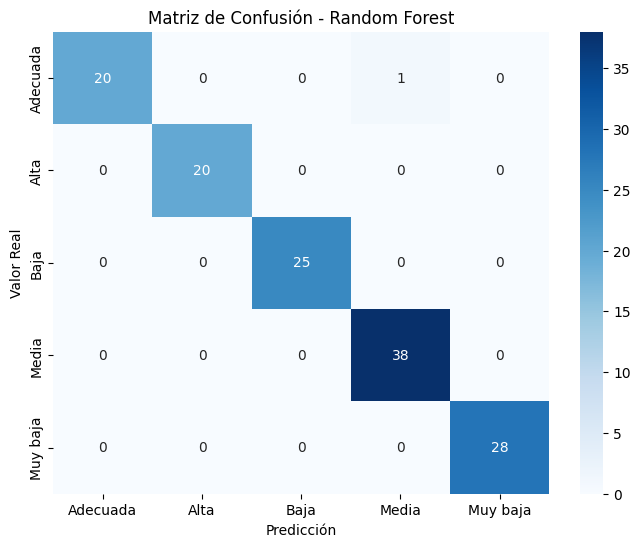

In [16]:
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=le_y.classes_,
    yticklabels=le_y.classes_
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

In [17]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(15)

,Variable,Importancia
13,cobertura_porcentaje,0.245057
4,cobertura_vacunacion,0.233146
12,cobertura_original,0.232150
5,estado_indicador,0.221768
3,biologico,0.038447
2,anio,0.011936
0,cod_departamento,0.010728
1,departamento,0.006769
6,rango_bajo_inicio,0.000000
7,rango_bajo_fin,0.000000


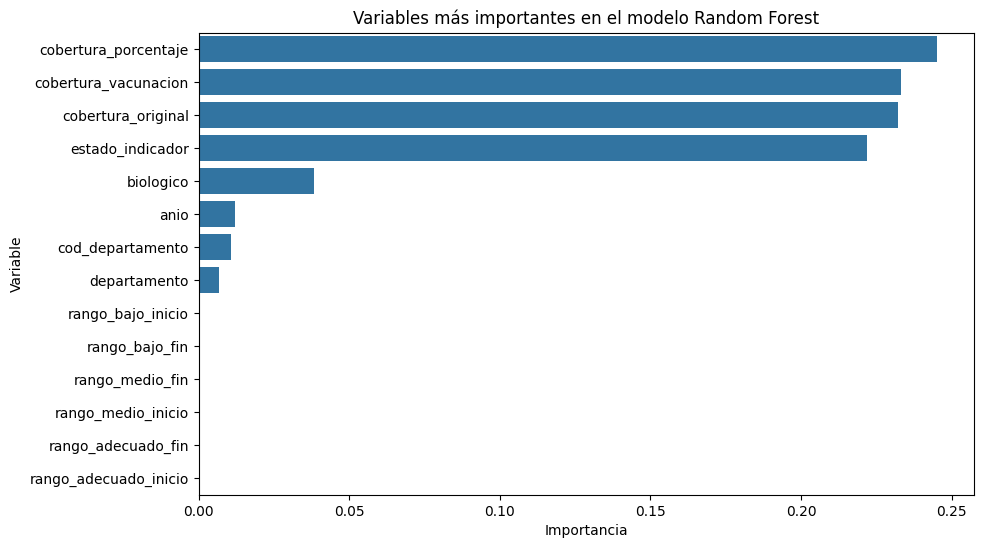

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias.head(15),
    x="Importancia",
    y="Variable"
)

plt.title("Variables más importantes en el modelo Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [19]:
import joblib

joblib.dump(modelo_rf, "../Modelos_entrenados/random_forest.pkl")

print("Modelo Random Forest guardado correctamente.")

Modelo Random Forest guardado correctamente.
